# LLM-as-a-Judge for Category-Level Insights

This notebook grades the output of `category_analysis_local.ipynb`
(`category_insights.json`) with an independent judge model — the same
pattern as `llm_as_judge.ipynb`, adapted to category-manager-style outputs.
`category_insights.json` now holds a `"categories"` array (one report per
category); this notebook judges every category in that array, and tags
each judged item with the category it came from.

**This notebook needs no split** — like `category_analysis_local.ipynb`, it
only makes API calls and reads a small JSON file; it never touches the raw
dataset or Kaggle.

Two things are judged, since they come from two different generation steps:

1. **Complaint themes** (from the Map-Reduce step) — is each theme actually
   supported by its attached sample comments, specific enough to act on, and
   not just noise?
2. **Brand comparison narrative** — does each brand's summary match the
   quantitative stats and sample comments it was given, is it balanced
   (not one-sided when evidence isn't), and is it actionable?

The judge model never re-fetches the original dataset — it only sees what
`category_insights.json` already contains (stats + sample comment
snippets), so grading is self-contained and reproducible.



## بخش ۱ — نصب و ایمپورت

In [1]:
import os
import json
import time
import re

import requests
import pandas as pd
import matplotlib.pyplot as plt


## بخش ۲ — تنظیمات، قیمت‌گذاری و بودجه

In [ ]:
INPUT_FILE = "category_insights.json"          # خروجی category_analysis.ipynb
OUTPUT_JSON = "category_judge_results.json"
OUTPUT_CSV = "category_judge_manual_review.csv"

RUN_MODE = "single"        # "single": فقط یک دسته داوری شود (سریع، برای تست) | "all": همه‌ی دسته‌های موجود در فایل
SELECTED_CATEGORY = None   # نام دقیق یا شماره‌ی دسته در لیستی که چاپ می‌شود؛ اگر None بماند و RUN_MODE="single"، همان لحظه از شما پرسیده می‌شود

API_URL = "https://api.metisai.ir/openai/v1/chat/completions"
API_KEY = os.environ.get("METIS_API_KEY", "*****")

GENERATOR_MODEL = "gpt-4o-mini"   # مدلی که تحلیل category_analysis.ipynb را تولید کرد
JUDGE_MODEL = "gpt-4o"            # مدل داور (عمداً متفاوت، برای جلوگیری از self-evaluation bias)

VALID_VERDICTS = {"pass", "fail"}

# ------------------------------------------------------------
# قیمت‌گذاری و بودجه (Placeholder — نرخ عمومی OpenAI؛ قبل از اجرای واقعی
# با نرخ دقیق حساب Metis AI خودتان جایگزین کنید)
# ------------------------------------------------------------
PRICING_PER_1M_TOKENS = {
    "gpt-4o-mini": {"input": 0.15, "output": 0.60},
    "gpt-4o": {"input": 2.50, "output": 10.00},
}
MAX_BUDGET_USD = 5.0

total_prompt_tokens = 0
total_completion_tokens = 0
total_cost_usd = 0.0


def estimate_cost(model, prompt_tokens, completion_tokens):
    rates = PRICING_PER_1M_TOKENS.get(model)
    if rates is None:
        return 0.0
    return (prompt_tokens / 1_000_000) * rates["input"] + (completion_tokens / 1_000_000) * rates["output"]


def budget_remaining():
    return total_cost_usd < MAX_BUDGET_USD


## بخش ۳ — بارگذاری گزارش‌های همه‌ی دسته‌ها

`category_insights.json` اکنون یک لیست از گزارش‌های دسته را زیر کلید
`"categories"` نگه می‌دارد؛ اسکیمای هر آیتم همان چیزی است که پیش‌تر
مستقیماً در ریشه‌ی فایل بود.

این سلول همچنان همه‌ی دسته‌های موجود در فایل را بارگذاری می‌کند (برای نمایش لیست در بخش بعد)؛ فیلتر کردن به یک دسته یا نگه‌داشتن همه، بر اساس `RUN_MODE` در سلول بعدی انجام می‌شود.


In [3]:
with open(INPUT_FILE, "r", encoding="utf-8") as f:
    insights_output = json.load(f)

all_category_reports = insights_output["categories"]

print("Categories loaded for judging:", len(all_category_reports))
for report in all_category_reports:
    n_themes = len(report.get("top_complaint_themes", []))
    n_brands = len(report.get("brand_comparison", {}).get("narrative", {}))
    print(f"  - {report['category']}: themes={n_themes}, brands={n_brands}")


Categories loaded for judging: 1
  - کنسول خانگی: themes=7, brands=3


## بخش ۳-الف — انتخاب دسته برای داوری (`RUN_MODE`)

اگر `category_insights.json` (خروجی نوت‌بوک قبلی در حالت `single`) از
همان ابتدا فقط یک دسته داشته باشد، همان یکی به‌طور خودکار انتخاب می‌شود.
اگر چند دسته داشته باشد و `RUN_MODE = "single"` باشد، لیست چاپ می‌شود و
باید یکی را با نام دقیق یا شماره‌اش انتخاب کنید (یا از قبل در
`SELECTED_CATEGORY` ست کرده باشید). اگر `RUN_MODE = "all"` باشد، همه‌ی
دسته‌های موجود در فایل داوری می‌شوند.


In [4]:
if RUN_MODE == "all" or len(all_category_reports) == 1:
    reports_to_judge = all_category_reports
    if RUN_MODE == "single" and len(all_category_reports) == 1:
        print(f"فقط یک دسته در فایل ورودی است -> همان به‌طور خودکار انتخاب شد: {all_category_reports[0]['category']}")
    else:
        print(f"RUN_MODE='all' -> همه‌ی {len(reports_to_judge)} دسته داوری می‌شوند (ممکن است طول بکشد).")

elif RUN_MODE == "single":
    print("دسته‌های موجود در فایل ورودی:")
    for i, report in enumerate(all_category_reports):
        n_themes = len(report.get("top_complaint_themes", []))
        n_brands = len(report.get("brand_comparison", {}).get("narrative", {}))
        print(f"  [{i}] {report['category']}  (themes={n_themes}, brands={n_brands})")

    def resolve_category(query, reports):
        query = str(query).strip()
        if query.isdigit():
            idx = int(query)
            if 0 <= idx < len(reports):
                return reports[idx]
            raise ValueError(f"ایندکس نامعتبر: {idx} (باید بین ۰ تا {len(reports) - 1} باشد)")
        exact = [r for r in reports if r["category"] == query]
        if exact:
            return exact[0]
        partial = [r for r in reports if query in r["category"]]
        if len(partial) == 1:
            return partial[0]
        if len(partial) > 1:
            names = "، ".join(r["category"] for r in partial)
            raise ValueError(f"چند دسته با «{query}» مطابقت دارند: {names} — دقیق‌تر بنویسید.")
        raise ValueError(f"دسته‌ای با نام/شماره‌ی «{query}» پیدا نشد.")

    query = SELECTED_CATEGORY
    if query is None:
        query = input("\nنام دقیق یا شماره‌ی دسته‌ی موردنظر را وارد کنید: ")

    selected_report = resolve_category(query, all_category_reports)
    reports_to_judge = [selected_report]
    print(f"\nانتخاب شد: {selected_report['category']}")

else:
    raise ValueError(f"RUN_MODE نامعتبر: {RUN_MODE!r} (باید 'single' یا 'all' باشد)")


فقط یک دسته در فایل ورودی است -> همان به‌طور خودکار انتخاب شد: کنسول خانگی


## بخش ۴ — تابع فراخوانی مدل داور و استخراج امن JSON

In [5]:
def call_judge(prompt, model=JUDGE_MODEL):
    headers = {"Content-Type": "application/json"}
    if API_KEY:
        headers["Authorization"] = f"Bearer {API_KEY}"

    payload = {
        "model": model,
        "messages": [
            {
                "role": "system",
                "content": (
                    "You are a strict, independent evaluator. "
                    "Always respond with valid JSON only, no extra text."
                ),
            },
            {"role": "user", "content": prompt},
        ],
        "temperature": 0,
    }

    start_time = time.perf_counter()
    response = requests.post(API_URL, headers=headers, json=payload, timeout=300)
    latency = time.perf_counter() - start_time

    response.raise_for_status()
    data = response.json()
    content = data["choices"][0]["message"]["content"]

    usage = data.get("usage", {})
    return content, latency, usage.get("prompt_tokens", 0), usage.get("completion_tokens", 0)


def extract_json(raw_text):
    text = raw_text.strip()
    text = re.sub(r"^```(json)?", "", text).strip()
    text = re.sub(r"```$", "", text).strip()

    match = re.search(r"\{.*\}", text, flags=re.DOTALL)
    if not match:
        raise ValueError(f"No JSON object found in judge response: {raw_text[:200]}")

    parsed = json.loads(match.group(0))
    required_keys = {"groundedness", "specificity", "actionability", "verdict", "reasoning"}
    if not required_keys.issubset(parsed.keys()):
        raise ValueError(f"Missing keys in judge response: {parsed}")
    if parsed["verdict"] not in VALID_VERDICTS:
        raise ValueError(f"Invalid verdict value: {parsed['verdict']}")

    return parsed


## بخش ۵ — داوری موضوعات شکایت (Complaint Themes)

هر موضوع بر اساس سه معیار داوری می‌شود:
- **Groundedness** — آیا نمونه نظرات پیوست‌شده واقعاً این موضوع را تأیید می‌کنند؟
- **Specificity** — آیا موضوع به‌قدر کافی مشخص و قابل‌اقدام است (نه یک عبارت کلی مثل «کیفیت پایین»)؟
- **Actionability** — آیا این موضوع برای تصمیم‌گیری یک مدیر دسته مفید است؟

In [6]:
def build_theme_judge_prompt(theme, category_name):
    snippets = theme.get("representative_comments", [])
    snippets_text = "\n".join(
        f"[ID {s['comment_id']}] {s['snippet']}" for s in snippets
    ) or "(هیچ نظر نمونه‌ای پیوست نشده است)"

    prompt = f"""
شما یک داور مستقل هستید که یک موضوع شکایت استخراج‌شده از نظرات دسته‌ی
"{category_name}" را ارزیابی می‌کنید.

موضوع ادعاشده: "{theme.get('theme')}"
تعداد تکرار ادعاشده: {theme.get('total_mentions')}

نمونه نظراتی که به‌عنوان شاهد برای این موضوع ارائه شده:
{snippets_text}

بر اساس فقط همین نمونه نظرات (نه دانش قبلی خودت درباره‌ی این دسته از
محصولات)، سه معیار زیر را از ۱ تا ۵ نمره بده:

1. groundedness: آیا نمونه نظرات واقعاً همین موضوع را تأیید می‌کنند؟
2. specificity: آیا موضوع به‌اندازه‌ی کافی مشخص و غیرکلی است؟
3. actionability: آیا این موضوع برای تصمیم‌گیری یک مدیر دسته‌ی محصول مفید است؟

سپس یک قضاوت نهایی "pass" یا "fail" بده (fail یعنی حداقل یکی از
معیارها، به‌خصوص groundedness، به‌طور جدی مشکل دارد).

فقط و فقط یک شیء JSON با دقیقاً همین ساختار برگردان:

{{
  "groundedness": <1-5>,
  "specificity": <1-5>,
  "actionability": <1-5>,
  "verdict": "pass" یا "fail",
  "reasoning": "توضیح کوتاه یک یا دو جمله‌ای"
}}
"""
    return prompt


## بخش ۶ — تابع ساخت Prompt داوری مقایسه‌ی برند

هر خلاصه‌ی برند بر اساس همان سه معیار (با تفسیر متناسب) داوری می‌شود؛
علاوه بر آن، تطابق خلاصه با آمار کمّی واقعی همان برند هم بخشی از
groundedness محسوب می‌شود. این بخش فقط تابع ساخت Prompt را تعریف می‌کند؛
فراخوانی واقعی در تابع داوری هر دسته (بخش ۷) انجام می‌شود.


In [7]:
def build_brand_judge_prompt(brand, summary, stats, samples, category_name):
    stats_text = json.dumps(stats, ensure_ascii=False)
    samples_text = "\n".join(
        f"[{s['sentiment']}] [ID {s['comment_id']}] {s['snippet']}" for s in samples
    ) or "(هیچ نظر نمونه‌ای پیوست نشده است)"

    prompt = f"""
شما یک داور مستقل هستید که خلاصه‌ی تولیدشده درباره‌ی برند "{brand}" در
دسته‌ی "{category_name}" را ارزیابی می‌کنید.

آمار کمّی واقعی این برند:
{stats_text}

نمونه نظرات واقعی (مثبت و منفی) این برند:
{samples_text}

خلاصه‌ی تولیدشده توسط سیستم:
"{summary}"

بر اساس فقط آمار و نمونه نظرات بالا (نه دانش قبلی خودت)، سه معیار زیر
را از ۱ تا ۵ نمره بده:

1. groundedness: آیا خلاصه با آمار و نمونه نظرات واقعی همخوانی دارد و
   ادعای بی‌اساس ندارد؟
2. specificity: آیا خلاصه مشخص و متمایزکننده است (نه یک جمله‌ی کلی که
   برای هر برندی صادق باشد)؟
3. actionability: آیا این خلاصه برای تصمیم‌گیری یک مدیر دسته مفید است؟

سپس یک قضاوت نهایی "pass" یا "fail" بده.

فقط و فقط یک شیء JSON با دقیقاً همین ساختار برگردان:

{{
  "groundedness": <1-5>,
  "specificity": <1-5>,
  "actionability": <1-5>,
  "verdict": "pass" یا "fail",
  "reasoning": "توضیح کوتاه یک یا دو جمله‌ای"
}}
"""
    return prompt


## بخش ۷ — تابع داوری کامل یک دسته (موضوعات شکایت + مقایسه‌ی برند)

داوری موضوعات شکایت و داوری مقایسه‌ی برند که پیش‌تر یک‌بار و برای یک
دسته اجرا می‌شدند، در تابع `judge_category` جمع شده‌اند تا در حلقه‌ی بخش
بعد، بدون تغییر، روی تک‌تک دسته‌ها اجرا شوند. هر آیتم داوری‌شده یک کلید
`"category"` هم می‌گیرد تا در تحلیل نهایی قابل ردیابی باشد — این تنها
افزوده‌ی جدید به اسکیمای قبلی است. بودجه (`MAX_BUDGET_USD`) میان همه‌ی
دسته‌ها مشترک است.


In [8]:
def judge_category(category_report):
    global total_prompt_tokens, total_completion_tokens, total_cost_usd

    category_name = category_report["category"]
    themes = category_report.get("top_complaint_themes", [])
    brand_comparison = category_report.get("brand_comparison", {})
    brand_stats = {row["Brand"]: row for row in brand_comparison.get("stats", [])}
    brand_samples = brand_comparison.get("sample_comments", {})
    brand_narrative = brand_comparison.get("narrative", {})

    results = []

    # --- داوری موضوعات شکایت ---
    for theme in themes:
        if not budget_remaining():
            print(f"    Budget limit reached — stopping theme judging for '{category_name}'.")
            break
        prompt = build_theme_judge_prompt(theme, category_name)
        try:
            raw_response, latency, prompt_tokens, completion_tokens = call_judge(prompt)
            call_cost = estimate_cost(JUDGE_MODEL, prompt_tokens, completion_tokens)
            total_prompt_tokens += prompt_tokens
            total_completion_tokens += completion_tokens
            total_cost_usd += call_cost

            scores = extract_json(raw_response)
            results.append({
                "category": category_name,
                "type": "complaint_theme",
                "subject": theme.get("theme"),
                "groundedness": scores["groundedness"],
                "specificity": scores["specificity"],
                "actionability": scores["actionability"],
                "verdict": scores["verdict"],
                "reasoning": scores["reasoning"],
                "cost_usd": call_cost,
                "evidence": theme.get("representative_comments", []),
            })
        except Exception as e:
            results.append({
                "category": category_name,
                "type": "complaint_theme",
                "subject": theme.get("theme"),
                "groundedness": None, "specificity": None, "actionability": None,
                "verdict": "error", "reasoning": str(e), "cost_usd": 0.0,
                "evidence": theme.get("representative_comments", []),
            })

    # --- داوری مقایسه‌ی برندها ---
    for brand, summary in brand_narrative.items():
        if not budget_remaining():
            print(f"    Budget limit reached — stopping brand judging for '{category_name}'.")
            break
        stats = brand_stats.get(brand, {})
        samples = brand_samples.get(brand, [])
        prompt = build_brand_judge_prompt(brand, summary, stats, samples, category_name)
        try:
            raw_response, latency, prompt_tokens, completion_tokens = call_judge(prompt)
            call_cost = estimate_cost(JUDGE_MODEL, prompt_tokens, completion_tokens)
            total_prompt_tokens += prompt_tokens
            total_completion_tokens += completion_tokens
            total_cost_usd += call_cost

            scores = extract_json(raw_response)
            results.append({
                "category": category_name,
                "type": "brand_comparison",
                "subject": brand,
                "groundedness": scores["groundedness"],
                "specificity": scores["specificity"],
                "actionability": scores["actionability"],
                "verdict": scores["verdict"],
                "reasoning": scores["reasoning"],
                "cost_usd": call_cost,
                "evidence": samples,
            })
        except Exception as e:
            results.append({
                "category": category_name,
                "type": "brand_comparison",
                "subject": brand,
                "groundedness": None, "specificity": None, "actionability": None,
                "verdict": "error", "reasoning": str(e), "cost_usd": 0.0,
                "evidence": samples,
            })

    return results


## بخش ۸ — اجرای داوری برای دسته(های) انتخاب‌شده (با Budget Guard)

حلقه‌ی زیر روی `reports_to_judge` اجرا می‌شود — که بسته به `RUN_MODE` یا
شامل یک دسته‌ی انتخاب‌شده است یا همه‌ی دسته‌های فایل ورودی. قبل از شروع
هر دسته، بودجه‌ی تجمعی چک می‌شود؛ با رسیدن به سقف، بقیه‌ی دسته‌ها بدون
فراخوانی رد می‌شوند.


In [9]:
judged_results = []

for idx, category_report in enumerate(reports_to_judge, start=1):
    category_name = category_report["category"]

    if not budget_remaining():
        print(f"\nBudget limit reached (${total_cost_usd:.4f} >= ${MAX_BUDGET_USD:.2f}). "
              f"Skipping remaining categories ({len(reports_to_judge) - idx + 1} left), "
              f"starting with '{category_name}'.")
        break

    print(f"\n[{idx}/{len(reports_to_judge)}] Judging category: {category_name}")
    category_results = judge_category(category_report)
    judged_results.extend(category_results)
    print(f"  -> judged items: {len(category_results)} | running cost: ${total_cost_usd:.4f}")

processed_categories = {r["category"] for r in judged_results}
print(f"\nCategories with at least one judged item: {len(processed_categories)} از {len(reports_to_judge)}")
print(f"Total judged items: {len(judged_results)}")



[1/1] Judging category: کنسول خانگی
  -> judged items: 10 | running cost: $0.0241

Categories with at least one judged item: 1 از 1
Total judged items: 10


## بخش ۹ — خلاصه‌ی مصرف توکن و هزینه

In [10]:
print("=" * 40)
print(f"Total prompt tokens:     {total_prompt_tokens}")
print(f"Total completion tokens: {total_completion_tokens}")
print(f"Total tokens:            {total_prompt_tokens + total_completion_tokens}")
print(f"Estimated total cost:    ${total_cost_usd:.4f}")
print(f"Budget limit:            ${MAX_BUDGET_USD:.2f}")
print(f"Remaining budget:        ${MAX_BUDGET_USD - total_cost_usd:.4f}")
print("=" * 40)


Total prompt tokens:     6550
Total completion tokens: 770
Total tokens:            7320
Estimated total cost:    $0.0241
Budget limit:            $5.00
Remaining budget:        $4.9759


## بخش ۱۰ — ذخیره‌سازی نتایج خام داوری (JSON)

In [11]:
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(judged_results, f, ensure_ascii=False, indent=2)

print(f"Saved JSON: {OUTPUT_JSON}")


Saved JSON: category_judge_results.json


## بخش ۱۱ — خلاصه‌ی آماری داوری (کلی + به‌تفکیک دسته)


In [12]:
df_judged = pd.DataFrame(judged_results)
valid = df_judged[df_judged["verdict"] != "error"]

print("Total judged:", len(df_judged))
print("Errors during judging:", (df_judged["verdict"] == "error").sum())

print("\nVerdict distribution overall:")
print(valid["verdict"].value_counts())

print("\nVerdict distribution by type:")
print(valid.groupby("type")["verdict"].value_counts())

print("\nAverage scores by type:")
print(valid.groupby("type")[["groundedness", "specificity", "actionability"]].mean().round(2))

print("\nAverage groundedness by category (ascending — weakest first):")
print(valid.groupby("category")["groundedness"].mean().round(2).sort_values())


Total judged: 10
Errors during judging: 0

Verdict distribution overall:
verdict
pass    9
fail    1
Name: count, dtype: int64

Verdict distribution by type:
type              verdict
brand_comparison  pass       3
complaint_theme   pass       6
                  fail       1
Name: count, dtype: int64

Average scores by type:
                  groundedness  specificity  actionability
type                                                      
brand_comparison           5.0         4.00            4.0
complaint_theme            4.0         3.43            4.0

Average groundedness by category (ascending — weakest first):
category
کنسول خانگی    4.3
Name: groundedness, dtype: float64


## بخش ۱۲ — نمودار توزیع نمرات

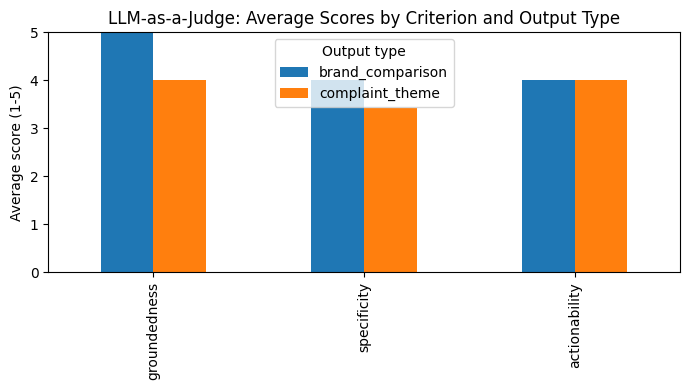

In [13]:
avg_by_type = valid.groupby("type")[["groundedness", "specificity", "actionability"]].mean()

avg_by_type.T.plot(kind="bar", figsize=(7, 4))
plt.ylim(0, 5)
plt.ylabel("Average score (1-5)")
plt.title("LLM-as-a-Judge: Average Scores by Criterion and Output Type")
plt.legend(title="Output type")
plt.tight_layout()
plt.show()


## بخش ۱۳ — ساخت CSV نهایی برای بررسی دستی (با ستون دسته)

مرتب‌شده بر اساس verdict و groundedness، تا موارد `fail` یا نمره‌ی پایین
اول دیده شوند. ستون `category` اضافه شده تا بشود نتایج را به‌تفکیک دسته
هم فیلتر کرد.


In [14]:
csv_rows = []

for result in judged_results:
    evidence_texts = []
    for e in result["evidence"]:
        evidence_texts.append(f"[{e.get('comment_id')}] {e.get('snippet')}")

    csv_rows.append({
        "category": result["category"],
        "type": result["type"],
        "subject": result["subject"],
        "groundedness": result["groundedness"],
        "specificity": result["specificity"],
        "actionability": result["actionability"],
        "verdict": result["verdict"],
        "reasoning": result["reasoning"],
        "cost_usd": result.get("cost_usd", 0.0),
        "evidence": "\n".join(evidence_texts),
    })

df_review = pd.DataFrame(csv_rows)
df_review = df_review.sort_values(["verdict", "groundedness"], ascending=[False, True])
df_review.to_csv(OUTPUT_CSV, index=False, encoding="utf-8-sig")

print(f"Saved: {OUTPUT_CSV}")
display(df_review.head(10))


Saved: category_judge_manual_review.csv


,category,type,subject,groundedness,specificity,actionability,verdict,reasoning,cost_usd,evidence
3,کنسول خانگی,complaint_theme,مشکلات عملکرد,4,3,4,pass,نظرات به مشکلات عملکردی مانند هنگ کردن و سرعت ...,0.001988,[54035234] بد نبود — خاطرات قدیم رو زنده میکنه...
5,کنسول خانگی,complaint_theme,بسته بندی نامناسب,4,3,4,pass,نظرات به موضوع بسته‌بندی نامناسب اشاره دارند، ...,0.001998,[49815177] nan — اینگار جنس دست دوم هست نه فرو...
6,کنسول خانگی,complaint_theme,مشکلات فنی,4,3,4,pass,نظرات به مشکلات فنی اشاره دارند، اما برخی نظرا...,0.002285,[53054385] خیلی بد — نخرید از دیجی کالا هیچی ن...
0,کنسول خانگی,complaint_theme,کیفیت پایین,5,3,4,pass,نظرات به‌وضوح به کیفیت پایین اشاره دارند، اما ...,0.001917,[25937313] nan — کیفیت پایین.اصلا بازی سگا نمی...
1,کنسول خانگی,complaint_theme,قیمت بالا,5,4,4,pass,نظرات به‌وضوح به موضوع قیمت بالا اشاره دارند و...,0.001978,[45457821] PS4 — کنسول خیلی خوبی ((بود)) ... و...
4,کنسول خانگی,complaint_theme,دستگاه معیوب یا دست دوم,5,4,5,pass,نظرات به وضوح به موضوع دستگاه معیوب یا دست دوم...,0.002007,[42585871] پلی استیشن خراب — کالای مورد نظر رو...
7,کنسول خانگی,brand_comparison,سونی,5,4,4,pass,خلاصه به خوبی با آمار و نظرات واقعی همخوانی دا...,0.003557,[44787458] یه دستگاه بی نقص و عالی — یک هفته م...
8,کنسول خانگی,brand_comparison,مایکروسافت,5,4,4,pass,خلاصه به خوبی با آمار و نظرات واقعی همخوانی دا...,0.003425,[43932524] یک نظر بی اغراق! — تصمیم خرید کنسول...
9,کنسول خانگی,brand_comparison,متفرقه,5,4,4,pass,خلاصه به خوبی با آمار و نظرات واقعی همخوانی دا...,0.003220,[52962775] کنسول اقتصادی Stick lite 4k — این ک...
2,کنسول خانگی,complaint_theme,حافظه کم,1,4,3,fail,نمونه نظرات ارائه شده هیچ اشاره‌ای به موضوع 'ح...,0.001700,[54335109] nan — در کل از خریدم راضی هستم، واق...
